# Task 1 — Behavioural Engagement Score (OULAD)

A **dynamic 0–100 engagement score** recomputed for every student every week, built
from five equally-weighted areas (20 points each):

| Area | What it captures | Source |
|---|---|---|
| 1. Activity | weekly clicks + active days | studentVle |
| 2. Breadth | distinct activity types touched | studentVle × vle |
| 3. Recency | days since last click | studentVle |
| 4. Relative standing | clicks vs. the cohort that week | studentVle |
| 5. Assessment | submission rate + timeliness + score | studentAssessment × assessments |

Because the score is calculated per *week*, plotting it over time gives an engagement
**trajectory** — the thing the brief actually cares about.

In [1]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- config (DATA_DIR points at the folder holding the OULAD csvs) ---
DATA_DIR     = os.environ.get("OULAD_DIR", "datasets")
MODULE       = None          # None = auto-pick the biggest course presentation
PRESENTATION = None

CLICKS_CAP_PCTL  = 0.90      # weekly clicks capped at this cohort percentile before scaling
TYPES_CAP        = 6         # >=6 activity types in a week = full breadth marks
RECENCY_MAX_DAYS = 21        # 3 weeks of silence => recency score 0
ASSESS_W_SUBMIT, ASSESS_W_ONTIME, ASSESS_W_SCORE = 0.4, 0.3, 0.3
DAYS_PER_WEEK = 7

## 1. Load the data and focus on one course presentation
Keeping one presentation means the weekly cohort comparison (Area 4) is apples-to-apples.

In [2]:
def _find(name):
    for f in os.listdir(DATA_DIR):
        if f.lower() == name.lower():
            return os.path.join(DATA_DIR, f)
    raise FileNotFoundError(f"Could not find '{name}' in '{DATA_DIR}'. Files: {os.listdir(DATA_DIR)}")

si  = pd.read_csv(_find("studentInfo.csv"))
sv  = pd.read_csv(_find("studentVle.csv"))
vle = pd.read_csv(_find("vle.csv"))
sa  = pd.read_csv(_find("studentAssessment.csv"))
asm = pd.read_csv(_find("assessments.csv"))

if MODULE is None or PRESENTATION is None:
    MODULE, PRESENTATION = (si.groupby(["code_module","code_presentation"]).size()
                              .sort_values(ascending=False).index[0])
print("Scoring:", MODULE, PRESENTATION)

si  = si[(si.code_module==MODULE) & (si.code_presentation==PRESENTATION)].copy()
sv  = sv[(sv.code_module==MODULE) & (sv.code_presentation==PRESENTATION)].copy()
vle = vle[(vle.code_module==MODULE) & (vle.code_presentation==PRESENTATION)].copy()
asm = asm[(asm.code_module==MODULE) & (asm.code_presentation==PRESENTATION)].copy()
asm = asm.dropna(subset=["date"]).copy()   # OULAD leaves some exam due-dates blank; drop them
sa  = sa[sa.id_assessment.isin(asm.id_assessment)].copy()
students = si[["id_student","final_result"]].drop_duplicates("id_student")
print(len(students), "students")

Scoring: CCC 2014J
2498 students


## 2. Build a week-by-week grid
One row per student per week, so every trajectory is continuous (silent weeks show up as zeros).

In [3]:
sv = sv[sv.date >= 0].copy()
sv["week"] = (sv.date // DAYS_PER_WEEK).astype(int)
max_week = int(sv.week.max())
if len(asm):
    max_week = max(max_week, int(asm.date.max() // DAYS_PER_WEEK))
weeks = np.arange(0, max_week + 1)

grid = (students[["id_student"]].assign(_k=1)
        .merge(pd.DataFrame({"week": weeks, "_k": 1}), on="_k").drop(columns="_k"))
grid["week_end_day"] = grid.week * DAYS_PER_WEEK + (DAYS_PER_WEEK - 1)
grid.head()

,id_student,week,week_end_day
0,23698,0,6
1,23698,1,13
2,23698,2,20
3,23698,3,27
4,23698,4,34


## Area 1 — Activity (clicks + active days)
How *much* and how *regularly* they engage. Active days separates a steady learner from a Sunday-night crammer.

In [4]:
wk = (sv.groupby(["id_student","week"])
        .agg(clicks=("sum_click","sum"), active_days=("date","nunique")).reset_index())
grid = grid.merge(wk, on=["id_student","week"], how="left")
grid[["clicks","active_days"]] = grid[["clicks","active_days"]].fillna(0)

## Area 2 — Breadth (distinct activity types)
Touching quizzes, forums and resources is healthier than hammering one page. Needs the join to `vle`.

In [5]:
svt = sv.merge(vle[["id_site","activity_type"]], on="id_site", how="left")
bt = svt.groupby(["id_student","week"]).activity_type.nunique().reset_index(name="n_types")
grid = grid.merge(bt, on=["id_student","week"], how="left")
grid["n_types"] = grid.n_types.fillna(0)

## Area 3 — Recency (days since last click)
The earliest warning sign of disengagement. Carried forward across silent weeks.

In [6]:
last_day = sv.groupby(["id_student","week"]).date.max().reset_index(name="last_active_day")
grid = grid.merge(last_day, on=["id_student","week"], how="left")
grid = grid.sort_values(["id_student","week"]).reset_index(drop=True)
grid["last_active_day"] = grid.groupby("id_student").last_active_day.ffill()
grid["recency_days"] = (grid.week_end_day - grid.last_active_day).fillna(RECENCY_MAX_DAYS).clip(lower=0)

## Area 4 — Relative standing (vs. the cohort)
Percentile of this week's clicks against everyone else that week — cancels out whole-class dips (holidays, exam weeks).

In [7]:
grid["rel_pct"] = grid.groupby("week").clicks.rank(pct=True)

## Area 5 — Assessment behaviour
Submission rate + on-time rate + average score, all cumulative.
Before the first assignment is due there is no data, so the area stays **neutral**
(set to the average of the other four) instead of unfairly scoring zero.

In [8]:
if len(asm) and len(sa):
    asm = asm.copy()
    asm["due_week"] = (asm.date // DAYS_PER_WEEK).astype(int)
    cum_due = asm.groupby("due_week").size().reindex(weeks, fill_value=0).cumsum()

    sub = (sa.merge(asm[["id_assessment","date"]], on="id_assessment", how="left")
             .rename(columns={"date":"due_day"}).dropna(subset=["date_submitted"]))
    sub["week"]   = (sub.date_submitted // DAYS_PER_WEEK).astype(int)
    sub["ontime"] = (sub.date_submitted <= sub.due_day).astype(int)
    sub["score"]  = pd.to_numeric(sub["score"], errors="coerce")

    subw = (sub.groupby(["id_student","week"])
              .agg(n_sub=("ontime","size"), n_ontime=("ontime","sum"),
                   score_sum=("score","sum"), score_cnt=("score","count")).reset_index())
    grid = grid.merge(subw, on=["id_student","week"], how="left")
    for c in ["n_sub","n_ontime","score_sum","score_cnt"]:
        grid[c] = grid[c].fillna(0)

    grid = grid.sort_values(["id_student","week"]).reset_index(drop=True)
    g = grid.groupby("id_student")
    grid["cum_sub"]       = g.n_sub.cumsum()
    grid["cum_ontime"]    = g.n_ontime.cumsum()
    grid["cum_score_sum"] = g.score_sum.cumsum()
    grid["cum_score_cnt"] = g.score_cnt.cumsum()
    grid["cum_due"]       = grid.week.map(cum_due)

    grid["submission_rate"] = (grid.cum_sub / grid.cum_due.replace(0, np.nan)).clip(0, 1)
    grid["ontime_rate"]     = (grid.cum_ontime / grid.cum_sub.replace(0, np.nan)).clip(0, 1)
    grid["avg_score"]       = (grid.cum_score_sum / grid.cum_score_cnt.replace(0, np.nan)) / 100.0
else:
    grid["submission_rate"] = np.nan; grid["ontime_rate"] = np.nan
    grid["avg_score"] = np.nan; grid["cum_due"] = 0

## Combine the five areas into a 0–100 score
Each area is scaled to 0–20 and summed. Constants live at the top so they are easy to tune and explain.

In [9]:
pos = grid.clicks[grid.clicks > 0]
clicks_cap = max(pos.quantile(CLICKS_CAP_PCTL), 1) if len(pos) else 1

grid["A1"] = 0.5*(np.minimum(grid.clicks, clicks_cap)/clicks_cap*20) + 0.5*(grid.active_days/DAYS_PER_WEEK*20)
grid["A2"] = np.minimum(grid.n_types, TYPES_CAP)/TYPES_CAP*20
grid["A3"] = (1 - np.minimum(grid.recency_days, RECENCY_MAX_DAYS)/RECENCY_MAX_DAYS)*20
grid["A4"] = grid.rel_pct*20
grid["A5_raw"] = 20*(ASSESS_W_SUBMIT*grid.submission_rate.fillna(0)
                     + ASSESS_W_ONTIME*grid.ontime_rate.fillna(0)
                     + ASSESS_W_SCORE*grid.avg_score.fillna(0))
no_assess_yet = grid.cum_due.fillna(0) == 0
grid["A5"] = np.where(no_assess_yet, grid[["A1","A2","A3","A4"]].mean(axis=1), grid.A5_raw)

grid["engagement_score"] = grid[["A1","A2","A3","A4","A5"]].sum(axis=1).clip(0, 100)
grid = grid.merge(students, on="id_student", how="left")

cols = ["id_student","week","clicks","active_days","n_types","recency_days","rel_pct",
        "submission_rate","ontime_rate","avg_score","A1","A2","A3","A4","A5",
        "engagement_score","final_result"]
grid[cols].round(2).to_csv("engagement_scores.csv", index=False)
grid[cols].head()

,id_student,week,clicks,active_days,n_types,recency_days,rel_pct,submission_rate,ontime_rate,avg_score,A1,A2,A3,A4,A5,engagement_score,final_result
0,23698,0,25.0,4.0,4.0,0.0,0.581465,NaN,NaN,NaN,7.327189,13.333333,20.000000,11.629303,13.072456,65.362282,Pass
1,23698,1,140.0,6.0,5.0,0.0,0.860689,NaN,NaN,NaN,17.603687,16.666667,20.000000,17.213771,17.871031,89.355155,Pass
2,23698,2,6.0,3.0,3.0,1.0,0.244195,0.0,NaN,NaN,4.672811,10.000000,19.047619,4.883907,0.000000,38.604337,Pass
3,23698,3,13.0,4.0,6.0,1.0,0.570056,1.0,0.0,0.78,6.552995,20.000000,19.047619,11.401121,12.680000,69.681735,Pass
4,23698,4,4.0,1.0,2.0,5.0,0.326661,1.0,0.5,0.86,1.686636,6.666667,15.238095,6.533227,16.160000,46.284624,Pass


## Five engagement archetypes
The selector finds one real student matching each pattern:
**steady engager**, **early dropout**, **late recoverer**, **high-effort struggler**
(busy but failing — proof of why a multi-area score beats click-counting), and
**crammer** (deadline-driven spikes).

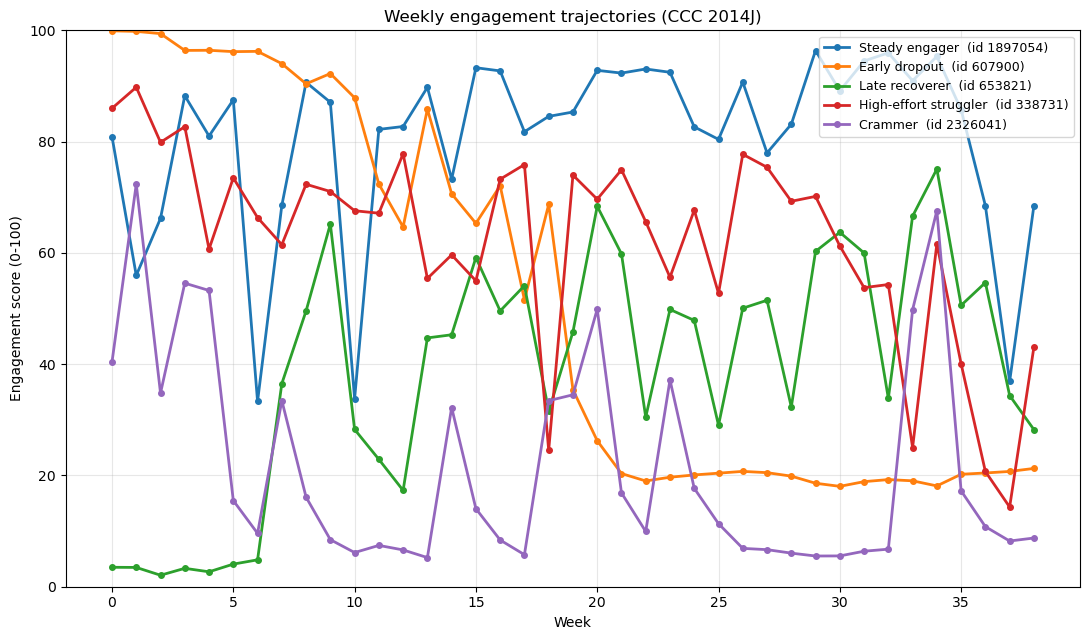

{'Steady engager': np.int64(1897054),
 'Early dropout': np.int64(607900),
 'Late recoverer': np.int64(653821),
 'High-effort struggler': np.int64(338731),
 'Crammer': np.int64(2326041)}

In [10]:
piv = grid.pivot_table(index="id_student", columns="week", values="engagement_score")
wkclicks = grid.pivot_table(index="id_student", columns="week", values="clicks").fillna(0)
ordered = sorted(piv.columns)
early_cols = [w for w in ordered if w <= 5]
late_cols  = [w for w in ordered if w >= max(ordered) - 5]
thirds = np.array_split(ordered, 3)
first_third, last_third = list(thirds[0]), list(thirds[-1])

summ = pd.DataFrame({
    "mean":  piv.mean(axis=1),
    "early": piv[early_cols].mean(axis=1),
    "late":  piv[late_cols].mean(axis=1),
    "cv":    wkclicks.std(axis=1) / wkclicks.mean(axis=1).replace(0, np.nan),
    "a1m":   grid.groupby("id_student").A1.mean(),
    "active_first": wkclicks[first_third].sum(axis=1) > 0,
    "active_last":  wkclicks[last_third].sum(axis=1) > 0,
})
due_mask = grid.cum_due.fillna(0) > 0
summ["a5m"] = grid[due_mask].groupby("id_student").A5.mean()
summ = summ.join(students.set_index("id_student"))
summ["gap"] = summ.late - summ.early
summ["steady_m"] = summ["mean"] - 2*summ.gap.abs()
summ["drop_m"]   = summ.early - summ.late
summ["effort_m"] = summ.a1m - summ.a5m.fillna(summ.a5m.median())
summ["cv"] = summ.cv.fillna(0)

chosen = set()
def pick(mask, by, ascending=False):
    pool = summ[mask & ~summ.index.isin(chosen)]
    if len(pool) == 0:
        pool = summ[~summ.index.isin(chosen)]
    sid = pool[by].sort_values(ascending=ascending).index[0]
    chosen.add(sid); return sid

passlike = summ.final_result.isin(["Pass","Distinction"])
archetypes = {
    "Steady engager":        pick(passlike, "steady_m"),
    "Early dropout":         pick(summ.final_result == "Withdrawn", "drop_m"),
    "Late recoverer":        pick(passlike, "gap"),
    "High-effort struggler": pick(summ.final_result == "Fail", "effort_m"),
    "Crammer":               pick(summ.active_first & summ.active_last, "cv"),
}

plt.figure(figsize=(11, 6.5))
for label, sid in archetypes.items():
    y = piv.loc[sid]
    plt.plot(y.index, y.values, marker="o", markersize=4, linewidth=2, label=f"{label}  (id {sid})")
plt.xlabel("Week"); plt.ylabel("Engagement score (0-100)")
plt.title(f"Weekly engagement trajectories ({MODULE} {PRESENTATION})")
plt.ylim(0, 100); plt.grid(alpha=0.3); plt.legend(fontsize=9)
plt.tight_layout(); plt.savefig("engagement_trajectories.png", dpi=120)
plt.show()
archetypes